In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
#vocab
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [4]:
#dataset
block_size = 3

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # slide the context window

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [9]:
n_embd = 10
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5) #* 0.2
#b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0

bnstd_running = torch.ones((1, n_hidden))



In [10]:
# Initialzing BatchNorm parameters
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))


In [11]:
parameters = [C, W1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

12097


In [21]:
hpreact.shape

torch.Size([32, 200])

In [22]:
#mean across 0th dim of hpreact
hpreact.mean(0, keepdim=True).shape #mean over all the elements in the batch

torch.Size([1, 200])

In [12]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  # Linear layer
  hpreact = embcat @ W1 #+ b1 # hidden layer pre-activation
 
    
    # BatchNorm layer

    
  bnmeani = hpreact.mean(0, keepdim=True)
  bnstdi = hpreact.std(0, keepdim=True)
  hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias
  with torch.no_grad():
    bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
    bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
  # -------------------------------------------------------------
  # Non-linearity
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  

      0/ 200000: 3.3239
  10000/ 200000: 2.0322
  20000/ 200000: 2.5675
  30000/ 200000: 2.0125
  40000/ 200000: 2.2446
  50000/ 200000: 1.8897
  60000/ 200000: 2.0785
  70000/ 200000: 2.3681
  80000/ 200000: 2.2918
  90000/ 200000: 2.0238
 100000/ 200000: 2.3673
 110000/ 200000: 2.3132
 120000/ 200000: 1.6414
 130000/ 200000: 1.9311
 140000/ 200000: 2.2231
 150000/ 200000: 2.0027
 160000/ 200000: 2.0997
 170000/ 200000: 2.4949
 180000/ 200000: 2.0199
 190000/ 200000: 2.1707


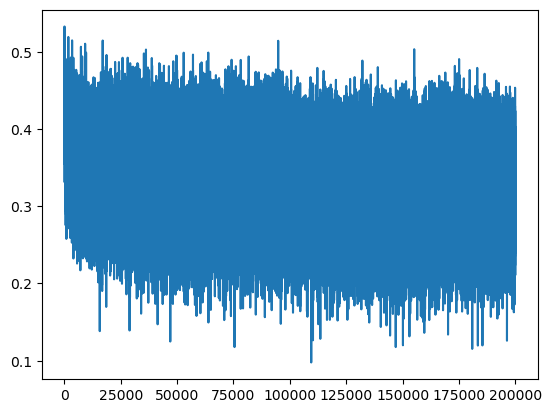

In [13]:
plt.plot(lossi) #no hockey stick appearance-good, no easy gains, hard gains. Optimization squashes down the weights at first

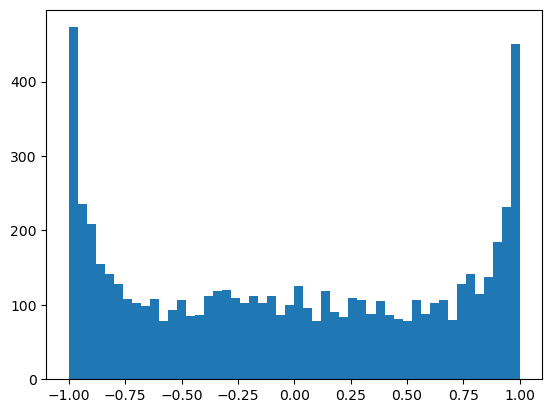

In [14]:
plt.hist(h.view(-1).tolist(),50); #tanh squashing at range 1,-1

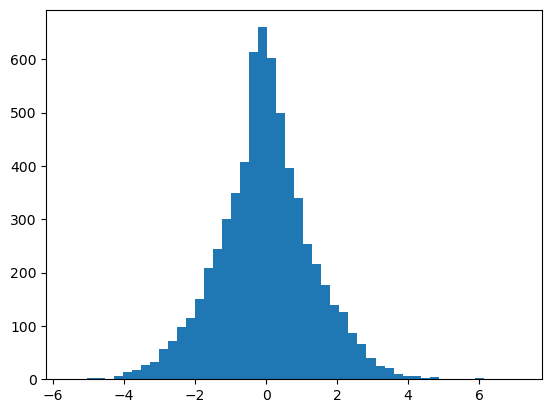

In [15]:
plt.hist(hpreact.view(-1).tolist(),50); #preactivation (before tanh)

In [5]:
-torch.tensor(1/27.0).log() #loss is negative log prob. This is uniform prob we expect at initialization, each char has 1/27 chance of being next

tensor(3.2958)

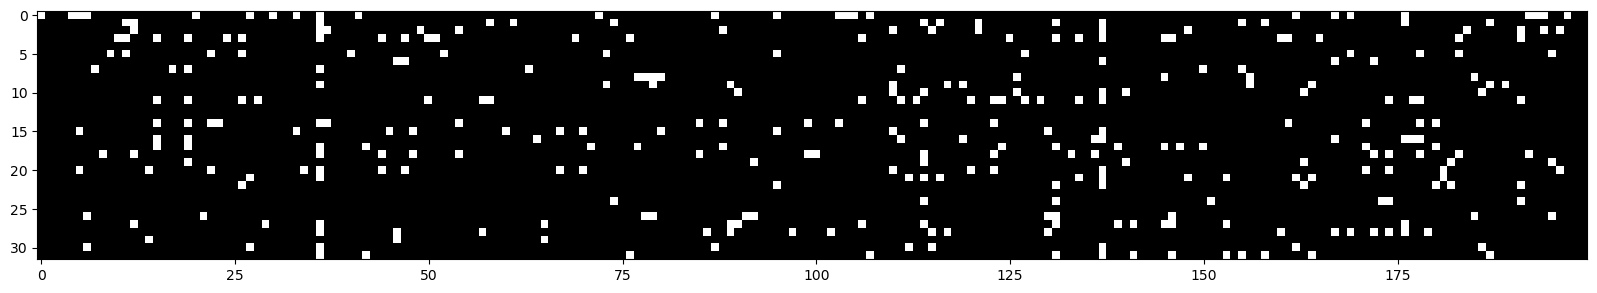

In [16]:
plt.figure(figsize =(20,10))
plt.imshow(h.abs()>0.99, cmap='gray', interpolation = 'nearest') #white if true, black if false(boolean tensor)
#30example 200 neurons

In [7]:
#4d example - 4 chars consideration
# logits = torch.tensor([0.0,0.0,2.0,0.0])
logits = torch.randn(4) * 10
probs = torch.softmax(logits,dim=0)
loss = -probs[2].log() #recording 2nd label, if we increase logit of 2nd then loss will reduce and it we increase any other then loss would increase
logits, probs, loss

(tensor([-13.1690,  -2.3874,  -3.8160,  -9.7315]),
 tensor([1.6752e-05, 8.0624e-01, 1.9323e-01, 5.2115e-04]),
 tensor(1.6439))

In [26]:
bnmeani

tensor([[-2.3139e+00,  1.0263e+00, -1.1909e+00,  1.8400e+00,  1.0465e+00,
          7.8725e-01,  1.0642e+00, -2.1538e+00,  2.3023e+00,  1.2206e+00,
         -2.1551e+00, -2.5148e+00,  8.3684e-01, -8.6518e-01,  2.4192e-01,
         -6.2726e-01,  1.3125e+00, -1.5929e+00, -5.5369e-02,  1.2023e+00,
         -8.4878e-01,  8.8570e-01, -1.1762e-02,  2.1140e-01,  8.9928e-01,
          1.6363e+00,  1.6117e+00,  1.1865e+00,  4.3311e-01,  1.1681e+00,
          5.4242e-01, -1.2880e+00,  4.3951e-01, -6.6181e-01,  8.4557e-02,
         -1.5637e+00, -2.7056e+00,  1.1945e-01,  1.1447e-03,  1.5197e-01,
         -3.7531e-01, -7.6991e-01, -3.1244e-02,  2.5885e-01,  7.5908e-01,
          6.0590e-01,  1.1042e+00, -3.9250e-01,  2.2504e+00,  7.0885e-01,
          1.4749e+00, -8.7415e-01,  1.8346e+00,  5.2918e-01,  9.5006e-01,
         -2.2732e+00,  7.7034e-01,  6.6668e-01, -4.5905e-02, -8.5436e-01,
         -3.0563e-01,  4.3210e-01,  7.7710e-05,  6.0588e-01,  6.2060e-01,
          1.9905e+00, -1.4370e+00,  2.

In [27]:
bnmean_running

tensor([[-2.4073e+00,  3.7330e-01, -1.2681e+00,  1.2967e+00,  9.6879e-01,
          9.8374e-01,  1.5422e+00, -1.9247e+00,  1.1060e+00,  1.2247e+00,
         -1.8296e+00, -2.7717e+00,  7.1378e-02, -6.1822e-01,  4.3368e-01,
         -6.6873e-01,  7.7062e-01, -2.1880e+00, -2.1886e-01,  1.5707e+00,
         -8.6626e-01,  1.0769e-01, -2.3912e-01,  4.1435e-01,  1.0355e+00,
          1.6324e+00,  1.1980e+00,  9.5799e-01,  3.5301e-01,  1.9479e+00,
         -8.0370e-02, -1.2021e+00, -9.8032e-02, -2.6652e-01, -4.7075e-01,
         -1.4911e+00, -2.6119e+00,  4.6961e-02, -3.0541e-04,  6.0433e-01,
         -2.3633e-01, -9.1247e-01, -2.8294e-01, -1.7835e-01,  6.5024e-01,
          9.0387e-01,  1.5864e+00, -3.9490e-01,  1.9726e+00,  1.0563e+00,
          1.7167e+00, -7.9533e-01,  2.0450e+00,  3.5586e-01,  5.4983e-01,
         -1.9198e+00, -3.1741e-02,  7.1272e-01,  9.0174e-01, -7.9930e-01,
         -6.7666e-01,  9.6928e-01,  4.8909e-01,  2.9599e-01,  1.1424e+00,
          1.6292e+00, -1.3298e+00,  2.

In [28]:
bnstdi

tensor([[2.0053, 1.9068, 1.6603, 1.8577, 2.6289, 2.7690, 2.8710, 2.1430, 2.8003,
         2.0228, 2.1222, 2.1526, 2.8401, 2.2251, 1.9155, 3.0245, 2.5482, 1.9029,
         2.0477, 2.5239, 2.3792, 2.3646, 2.0176, 2.3043, 2.3174, 1.9534, 2.6430,
         2.8744, 2.6882, 2.7529, 1.8852, 2.4465, 1.9907, 2.0410, 2.3439, 2.1722,
         2.8544, 1.7728, 1.8121, 2.0525, 2.2400, 2.0570, 2.5825, 2.2955, 1.7698,
         2.4236, 2.2853, 2.9722, 2.1299, 2.9704, 2.0805, 2.3796, 2.0467, 1.7726,
         3.5133, 2.5041, 1.6261, 2.0474, 2.8937, 1.4966, 2.0082, 2.1093, 2.0519,
         2.4574, 2.3704, 1.7196, 1.6663, 2.6221, 1.9981, 2.6777, 2.5342, 2.7175,
         2.3081, 2.7709, 1.8701, 1.4729, 2.7530, 1.8882, 2.1550, 2.8331, 2.2585,
         1.7051, 1.8696, 2.1866, 3.4499, 2.2461, 2.4442, 2.3263, 2.1067, 2.5492,
         1.9914, 1.5185, 2.6196, 1.9545, 1.7296, 2.4934, 2.0081, 2.0182, 1.7530,
         2.4831, 2.3304, 1.9306, 1.8609, 1.8745, 2.3892, 2.6562, 2.0816, 2.4946,
         1.5796, 2.1609, 2.6

In [29]:
bnstd_running

tensor([[2.2928, 1.9427, 1.9364, 2.0953, 2.2995, 2.4166, 2.1407, 2.2075, 2.2234,
         2.0265, 2.4173, 2.2320, 2.0377, 2.1739, 1.9096, 2.7113, 2.3809, 1.8600,
         2.1484, 2.2797, 2.1495, 2.4298, 2.0392, 2.1228, 2.0473, 1.9589, 2.1623,
         2.6292, 2.4343, 2.3131, 1.6525, 1.8554, 2.0204, 1.8838, 2.1689, 1.9952,
         2.6060, 2.0437, 1.7075, 1.8660, 2.0990, 2.0294, 2.4064, 1.9573, 2.0846,
         2.3917, 2.1113, 2.6155, 2.2781, 2.5159, 2.0995, 1.8716, 1.7738, 1.7283,
         2.3768, 2.2484, 1.8444, 2.2612, 2.4763, 1.7612, 2.2516, 2.1111, 2.0801,
         2.3640, 2.1600, 2.1135, 2.1172, 2.3802, 1.9236, 2.1764, 2.1883, 1.9734,
         1.9851, 2.3053, 1.8851, 1.7038, 2.5969, 2.1507, 1.7744, 2.3817, 2.1906,
         1.7303, 1.9745, 2.1958, 2.4254, 2.2609, 2.1657, 2.3311, 2.2450, 2.4851,
         2.0233, 1.9877, 2.1218, 1.9063, 1.9406, 2.4071, 2.1017, 1.9552, 1.8929,
         2.2080, 2.1181, 1.9114, 2.2727, 2.1310, 1.9626, 2.1952, 2.0506, 2.1475,
         1.8702, 2.0897, 2.4

In [17]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 # + b1 #batch norm has its own bias dont need to add it in prev layer
  #hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
  hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0674145221710205
val 2.1056838035583496


tensor(-0.0218) tensor(1.0031)
tensor(-6.5143e-05) tensor(1.0108)


(array([1.10667147e-04, 8.85337177e-05, 8.85337177e-05, 1.54934006e-04,
        4.42668589e-04, 4.86935447e-04, 7.52536601e-04, 1.83707464e-03,
        3.07654669e-03, 4.58161989e-03, 7.59176629e-03, 1.25275211e-02,
        2.06947565e-02, 3.00571972e-02, 4.72548718e-02, 7.11368422e-02,
        9.85380278e-02, 1.38754469e-01, 1.90236826e-01, 2.44906397e-01,
        3.10598415e-01, 3.68499467e-01, 4.03094017e-01, 4.24806911e-01,
        4.07232968e-01, 3.77884041e-01, 3.22816068e-01, 2.59514460e-01,
        2.01480608e-01, 1.52145194e-01, 1.11109816e-01, 7.43683229e-02,
        5.05970197e-02, 3.24476075e-02, 2.19563620e-02, 1.31029902e-02,
        9.14110635e-03, 5.46695707e-03, 2.65601153e-03, 2.16907608e-03,
        1.04027118e-03, 5.31202306e-04, 2.43467724e-04, 3.09868012e-04,
        8.85337177e-05, 0.00000000e+00, 4.42668589e-05, 0.00000000e+00,
        0.00000000e+00, 2.21334294e-05]),
 array([-5.33303881, -5.10713617, -4.88123354, -4.65533091, -4.42942827,
        -4.20352564, 

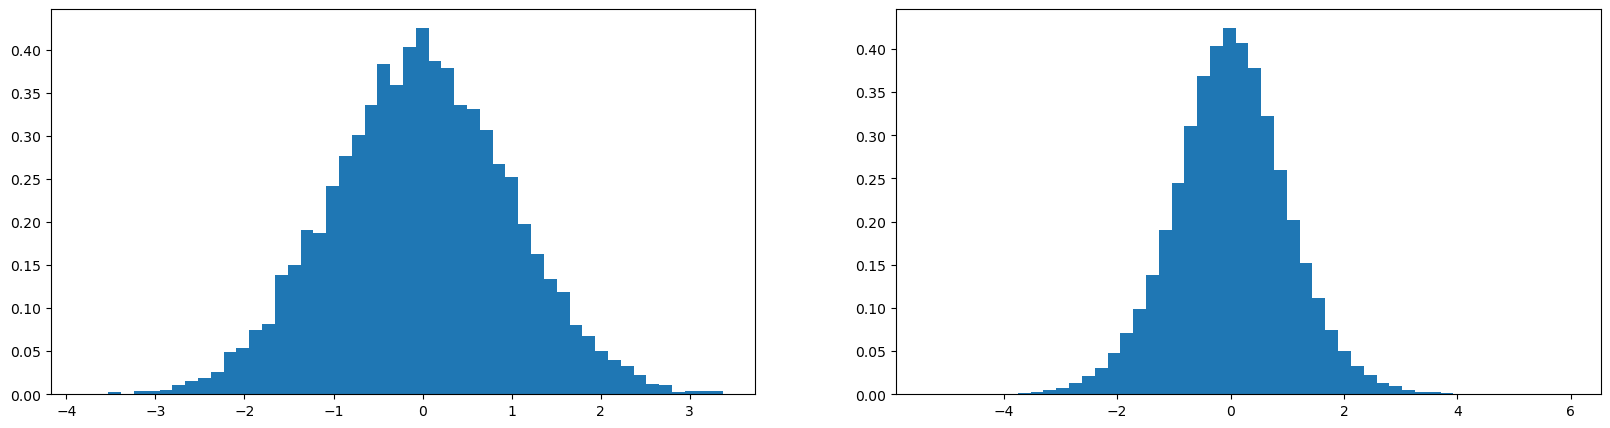

In [30]:
x = torch.randn(1000,10) #1k examples, 10 dimension drawn from gaussian
w = torch.randn(10,200) #10 inputs, 200 neurons randomly drawn from gaussian
w /= 10**0.5
y = x @ w #forget about biases and non linearity currently
print(x.mean(),x.std())
print(y.mean(),y.std())
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density = True)
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density = True)

## Pytorch Internals

In [23]:
#Pytorch linear layer and batchnorm internals declaration
#training stats is true->we are calculating running mean and var
class Linear:
  
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5 #Kaiming initialization
    self.bias = torch.zeros(fan_out) if bias else None
  
  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out
  
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:
  
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True #by default flag necessary and needs to be true
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)
  
  def __call__(self, x):
    #  forward pass
    if self.training: #during training calc and use mean and var from current batch
      xmean = x.mean(0, keepdim=True) # batch mean
      xvar = x.var(0, keepdim=True) # batch variance
    else: #during inference use running mean and variance
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta #for stats-not in pytorch implementation
    # update the buffers (running mean and var are called buffers in pytorch nomenclature)
    if self.training: #if training update mean and var else keep it fixed
      with torch.no_grad(): #context manager->pytorch expects we will call .backward for this calc and it will build computation graph but we will never call it in running mean and var calculation; this saves memory and makes it more efficient
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out
  
  def parameters(self):
    return [self.gamma, self.beta]

class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []



In [24]:
n_embd = 10 
n_hidden = 100 
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd),            generator=g)
#6 layers mlp
layers = [
  Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, vocab_size, bias=False), BatchNorm1d(vocab_size),
]

In [40]:
with torch.no_grad():
  # last layer: make less confident
  layers[-1].gamma *= 0.1
  #layers[-1].weight *= 0.1
  # all other layers: apply gain
  for layer in layers[:-1]:
    if isinstance(layer, Linear):
      layer.weight *= 5/3 #5/3, try 1 and all layer will shrink to 0

parameters = [C] + [p for layer in layers for p in layer.parameters()] #for every parameter in each layer in layers
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

47024


In [41]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  x = emb.view(emb.shape[0], -1) # concatenate the vectors
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb) # loss function
  
  # backward pass
  for layer in layers:
    layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  with torch.no_grad():
    ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

  if i >= 1000:
    break # AFTER_DEBUG: would take out obviously to run full optimization

      0/ 200000: 2.7844


layer 2 (      Tanh): mean -0.00, std 0.63, saturated: 3.31%
layer 5 (      Tanh): mean -0.00, std 0.64, saturated: 2.75%
layer 8 (      Tanh): mean +0.00, std 0.65, saturated: 2.69%
layer 11 (      Tanh): mean +0.00, std 0.65, saturated: 2.31%
layer 14 (      Tanh): mean -0.00, std 0.66, saturated: 1.91%


Text(0.5, 1.0, 'activation distribution')

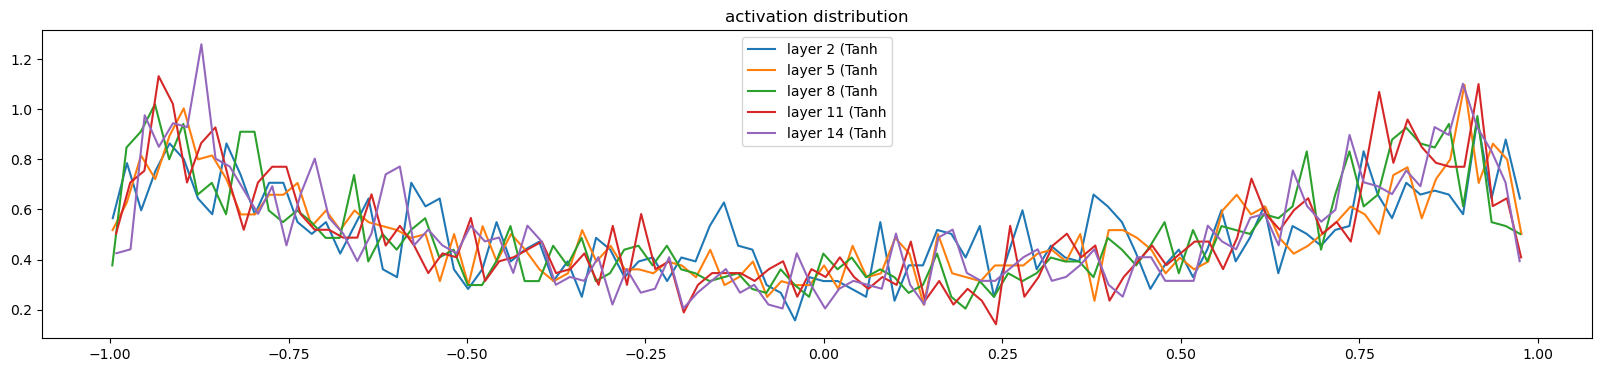

In [42]:
# visualize histograms
#without gain or weights += 1 in linear layer, std is shrinking and saturation is coming to 0 i.e all the layers are shrinking to 0 in graph
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

layer 2 (      Tanh): mean -0.000000, std 2.640701e-03
layer 5 (      Tanh): mean +0.000000, std 2.245583e-03
layer 8 (      Tanh): mean +0.000000, std 2.045741e-03
layer 11 (      Tanh): mean -0.000000, std 1.983133e-03
layer 14 (      Tanh): mean -0.000000, std 1.952382e-03


Text(0.5, 1.0, 'gradient distribution')

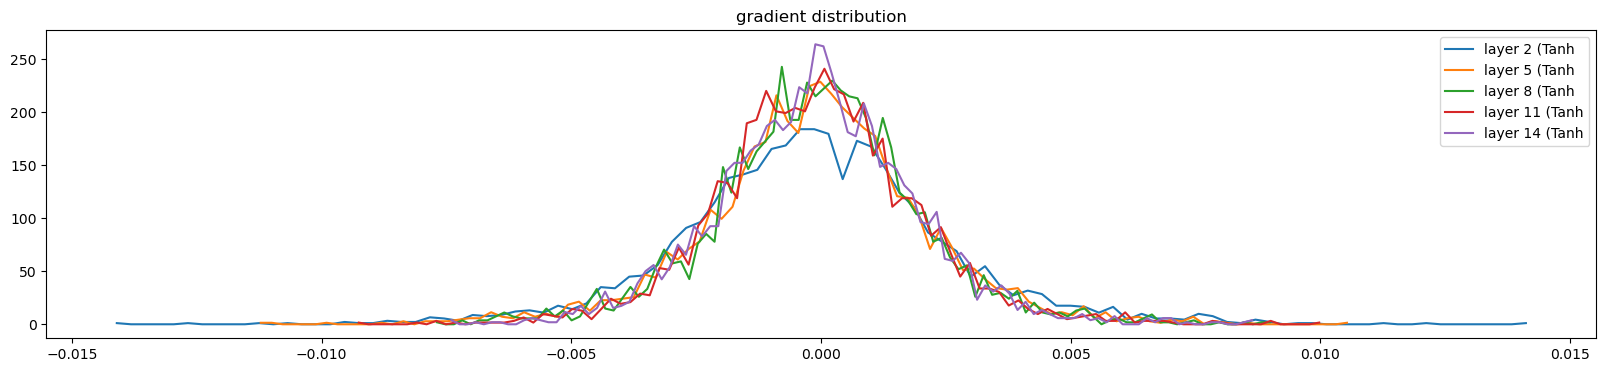

In [34]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

weight   (27, 10) | mean +0.000000 | std 8.020530e-03 | grad:data ratio 8.012625e-03
weight  (30, 100) | mean +0.000246 | std 9.241069e-03 | grad:data ratio 4.881087e-02
weight (100, 100) | mean +0.000113 | std 7.132874e-03 | grad:data ratio 6.964614e-02
weight (100, 100) | mean -0.000086 | std 6.234300e-03 | grad:data ratio 6.073736e-02
weight (100, 100) | mean +0.000052 | std 5.742185e-03 | grad:data ratio 5.631480e-02
weight (100, 100) | mean +0.000032 | std 5.672203e-03 | grad:data ratio 5.570124e-02
weight  (100, 27) | mean -0.000082 | std 1.209416e-02 | grad:data ratio 1.160106e-01


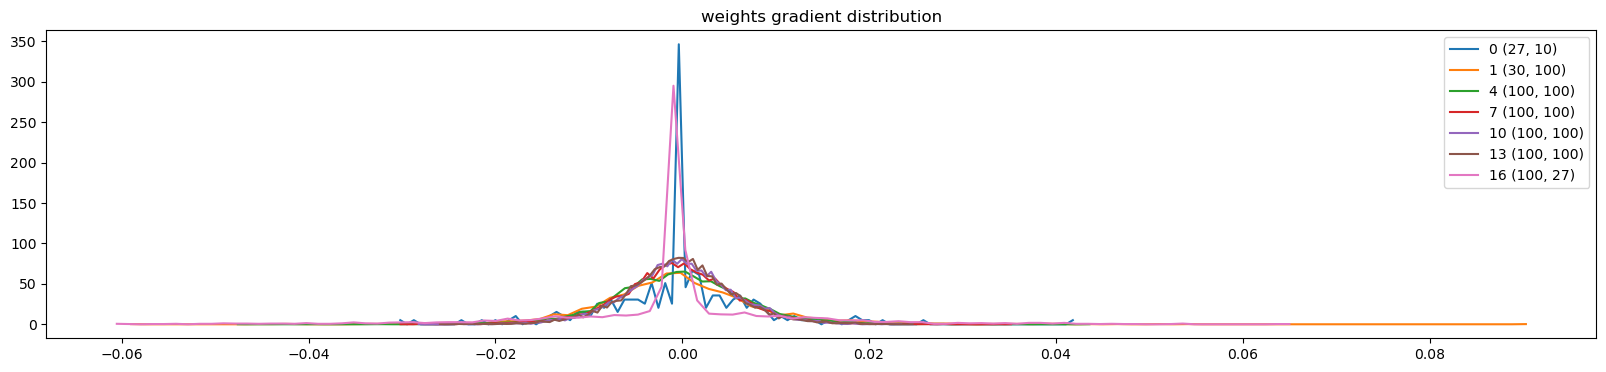

In [35]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

In [ ]:
#why tanh? multiple linears only collapse to single neural layer in terms of its representation power